# YOLO Cow Detection: Inference Pipeline

This notebook runs the complete YOLO cow-detection inference flow: configuration, source, transforms, dataset, PyTorch dataloader, resolved model artifact, model provider, predictor, and rich results.

The model runtime does not locate or download weights. This notebook resolves the local artifact explicitly before injecting it into `YOLOModelProvider`.

## Section 1: Setup and configuration

In [1]:
import os
from pathlib import Path

from bovi_core.config import Config
from bovi_core.ml import ModelProviderRegistry
from bovi_core.utils.path_utils import get_project_root
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(usecwd=True))
repo_root = Path(get_project_root(project_name="bovi"))
asset_root = Path(os.environ.get("YOLO_MODEL_LOCAL_ROOT", repo_root))
config_path = repo_root / "data/experiments/yolo/versions/v1/config/config.yaml"
runtime_project_path = asset_root / "pyproject.toml"
model_project_path = repo_root / "packages/models/bovi-yolo/pyproject.toml"

Config.reset()
config = Config(
    config_file_path=str(config_path),
    project_file_path=str(runtime_project_path),
)

print(f"Environment: {config.environment}")
print(f"Configuration: {config_path}")
print(f"Asset root: {asset_root}")
print(f"Available providers: {ModelProviderRegistry.list_available()}")

🔍 Found pyproject.toml in parent directory: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example
      📋 Project name: bovi
      📁 Current working directory: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/packages/models/bovi-yolo/notebooks/experiments/yolo
      📁 Traversed to: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example
🔄 Config singleton reset
🔧 Initializing Config...
   🌍 Environment: local
🔍 No experiment_name passed, resolving from config_file_path: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/data/experiments/yolo/versions/v1/config/config.yaml
      🧪 Resolved experiment_name: yolo
      📁 project_src: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/packages/models/bovi-yolo/src
⚠️  .env file not specified or not found at: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/.env
   👤 Author: Douwe de 

In [2]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=3, suppress=True, threshold=10)
plt.rcParams["figure.dpi"] = 80

model_node = config.experiment.models.yolo
inference_node = model_node.inference
prediction_kwargs = {
    "conf": float(inference_node.conf),
    "iou": float(inference_node.iou),
    "imgsz": int(inference_node.imgsz),
    "verbose": False,
}

print(f"Experiment: {config.experiment.experiment_name}")
print(f"Framework: {model_node.framework}")
print(f"Inference arguments: {prediction_kwargs}")

Experiment: yolo
Framework: pytorch
Inference arguments: {'conf': 0.25, 'iou': 0.45, 'imgsz': 640, 'verbose': False}


## Section 2: Source and raw image

In [3]:
from bovi_yolo.dataloaders import YOLODataLoaderConfig, create_source

data_config = YOLODataLoaderConfig.from_config(config, split="inference")
source = create_source(data_config.source)
metadata = source.get_metadata(0)

print(f"Loaded {len(source)} image(s) from {type(source).__name__}")
for key, value in metadata.items():
    print(f"  {key}: {value}")

Loaded 1 image(s) from LocalFileSource
  path: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/data/experiments/yolo/input/test/images/example_cow_image_barn.jpg
  filename: example_cow_image_barn.jpg
  label: images
  size_bytes: 2832976
  modified: 2026-09-02T10:54:49.603071+00:00


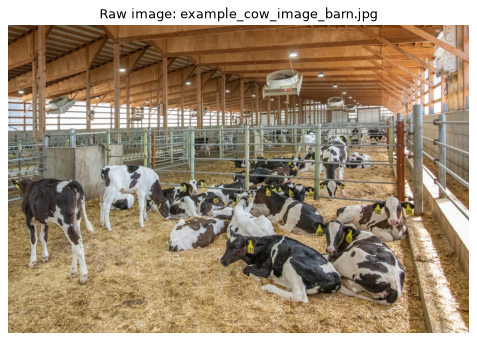

Original image size: (4044, 2700)


In [4]:
from io import BytesIO

from PIL import Image

image = Image.open(BytesIO(source.load_item(0))).convert("RGB")
preview = image.copy()
preview.thumbnail((1000, 700))

plt.figure(figsize=(8, 5))
plt.imshow(preview)
plt.title(f"Raw image: {metadata['filename']}")
plt.axis("off")
plt.show()

print(f"Original image size: {image.size}")

## Section 3: Configured vision transforms

In [5]:
from bovi_core.ml.dataloaders.transforms import TransformRegistry, build_vision_pipeline

inference_loader_config = model_node.dataloaders.inference
transforms = TransformRegistry.from_config(inference_loader_config.transforms)
vision_pipeline = build_vision_pipeline(inference_loader_config.transforms)

print(f"Created {len(transforms)} transforms in order:")
for spec in inference_loader_config.transforms:
    print(f"  - {spec['name']}")

Created 2 transforms in order:
  - image_validation
  - image_resize


In [6]:
sample = np.asarray(image)
transformed = vision_pipeline(image=sample)["image"]

print(f"Before: shape={sample.shape}, dtype={sample.dtype}")
print(f"After:  shape={transformed.shape}, dtype={transformed.dtype}")

try:
    vision_pipeline(image=np.zeros((10, 10), dtype=np.uint8))
except (TypeError, ValueError) as exc:
    print(f"Invalid image correctly rejected: {exc}")

Before: shape=(2700, 4044, 3), dtype=uint8
After:  shape=(640, 640, 3), dtype=uint8
Invalid image correctly rejected: Expected 3D array (H, W, C), got 2D


## Section 4: Dataset and PyTorch dataloader

In [7]:
from bovi_yolo.dataloaders.dataset import YOLODataset

# The dataset remains NumPy-first and does not apply transforms itself.
dataset = YOLODataset(source=source)
item = dataset[0]

print(f"Dataset size: {len(dataset)}")
print(f"Image: shape={item['image'].shape}, dtype={item['image'].dtype}")
print(f"Split label: {item['label']}")
print(f"Metadata keys: {list(item['metadata'])}")

Dataset size: 1
Image: shape=(2700, 4044, 3), dtype=uint8
Split label: test
Metadata keys: ['path', 'filename', 'label', 'size_bytes', 'modified', 'height', 'width']


In [8]:
from bovi_core.ml import create_dataloader
from bovi_yolo.dataloaders import YOLODataLoaderConfig
from bovi_yolo.models import YOLOModelConfig

# Core discovers the package factory; the package still owns composition.
data_config = YOLODataLoaderConfig.from_config(config, split="inference")
model_config = YOLOModelConfig.from_config(config)
dataloader = create_dataloader("yolo", data_config, model_config)
batch = next(iter(dataloader))

print(f"Batches: {len(dataloader)}")
print(f"Batch image: shape={tuple(batch['image'].shape)}, dtype={batch['image'].dtype}")
print(f"Batch labels: {batch['label']}")

Batches: 1
Batch image: shape=(1, 3, 640, 640), dtype=torch.float32
Batch labels: ['test']


## Section 5: Resolve and load the model

In [9]:
from ultralytics.utils.downloads import attempt_download_asset

artifact_path = Path(model_node.local_weights.default)
if not artifact_path.is_file():
    artifact_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Resolving Ultralytics asset to {artifact_path}")
    attempt_download_asset(artifact_path)

if not artifact_path.is_file():
    raise FileNotFoundError(f"Could not resolve YOLO weights: {artifact_path}")

print(f"Resolved weights: {artifact_path} ({artifact_path.stat().st_size / 1_000_000:.1f} MB)")

Resolved weights: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/data/experiments/yolo/versions/v1/weights/yolo12n.pt (5.6 MB)


In [10]:
from bovi_core.ml import PredictorRegistry, ResolvedModelArtifact
from bovi_yolo.models import YOLOModelConfig

model_config = YOLOModelConfig.from_config(config)
artifact = ResolvedModelArtifact(
    format="ultralytics-pt",
    source_uri=artifact_path.resolve().as_uri(),
    local_path=artifact_path,
)
provider = ModelProviderRegistry.create("yolo")
model = provider.load_artifact(model_config, artifact)
predictor = PredictorRegistry.create("yolo", model=model, config=config)

print(f"Model config: {model_config}")
print(f"Runtime model: {type(model).__name__}")
print(f"Native model: {type(model.native_model).__name__}")
print(f"Device: {model.native_model.device}")

Model config: framework='pytorch' model_source='yolo12n.yaml' task='detect'
Runtime model: YOLOModel
Native model: YOLO
Device: cpu


In [11]:
# Fresh construction is a separate lifecycle capability and does not use weights.
fresh_model = provider.create(model_config)
print(f"Fresh runtime: {type(fresh_model).__name__}")
print(f"Architecture source: {model_config.model_source}")

Fresh runtime: YOLOModel
Architecture source: yolo12n.yaml


## Section 6: Native training, evaluation and checkpoint restore

Detection training uses the labelled Ultralytics dataset YAML directly. The Bovi dataloader above remains an inference pipeline and is not used to invent a separate bounding-box loss.

In [ ]:
from uuid import uuid4

from bovi_core.ml import EvaluationContext, TrainingContext
from bovi_core.ml.models.checkpoints import LocalCheckpointResolver
from bovi_yolo import (
    YOLOEvaluationConfig,
    YOLOEvaluator,
    YOLOTrainer,
    YOLOTrainingConfig,
)

run_root = asset_root / "data/experiments/yolo/output/notebook"
training_context = TrainingContext(run_id=uuid4(), output_dir=run_root / "training")
training_config = YOLOTrainingConfig.from_config(config)
training_model = provider.create(model_config)
training_result = YOLOTrainer(
    model=training_model,
    dataloaders={},
    config=training_config,
    context=training_context,
).train()
print(training_result.model_dump(mode="json"))

if training_result.best_checkpoint is None:
    raise RuntimeError(f"Training did not create a checkpoint: {training_result.issues}")
resolved_checkpoint = LocalCheckpointResolver().resolve(training_result.best_checkpoint)
restored_model = provider.restore_checkpoint(model_config, resolved_checkpoint)

evaluation_context = EvaluationContext(
    evaluation_id=uuid4(),
    output_dir=run_root / "evaluation",
    split="validation",
    model_version=str(training_context.run_id),
    training_run_id=training_context.run_id,
)
evaluation_result = YOLOEvaluator(
    restored_model, YOLOEvaluationConfig.from_config(config)
).evaluate(dataloader, evaluation_context)
print(evaluation_result.model_dump(mode="json"))

## Section 7: Predict and inspect results

In [12]:
input_image = item["image"]
raw_result = predictor.predict(input_image, return_format="raw", **prediction_kwargs)
base_result = predictor.predict(input_image, return_format="base", **prediction_kwargs)
rich_result = predictor.predict(input_image, return_format="rich", **prediction_kwargs)

print(f"Raw result type: {type(raw_result).__name__}")
print(f"Base result keys: {list(base_result)}")
print(f"Rich result type: {type(rich_result).__name__}")
print(f"Detections: {rich_result.num_predictions}")
print(f"Classes: {rich_result.class_names}")
print(f"Scores: {rich_result.scores}")

Raw result type: list
Base result keys: ['boxes_xyxy', 'class_ids', 'class_names', 'scores', 'num_predictions', 'has_masks', 'metadata']
Rich result type: YoloPredictionResult
Detections: 6
Classes: ['cow', 'cow', 'cow', 'cow', 'cow', 'cow']
Scores: [    0.88455     0.81164      0.8066      0.6304     0.56415     0.31992]


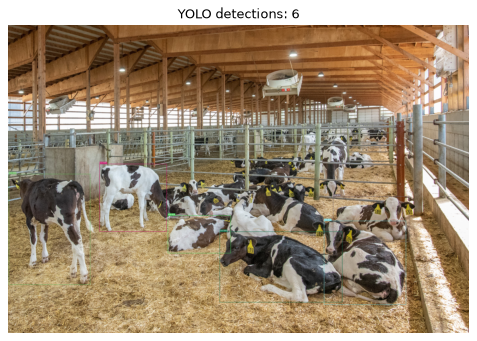

In [13]:
annotated = rich_result.draw_on_image()
annotated_preview = Image.fromarray(annotated)
annotated_preview.thumbnail((1000, 700))

plt.figure(figsize=(8, 5))
plt.imshow(annotated_preview)
plt.title(f"YOLO detections: {rich_result.num_predictions}")
plt.axis("off")
plt.show()

In [14]:
filtered = rich_result.filter_by_confidence(0.5)
crops = rich_result.get_crops()

print(f"Detections with confidence >= 0.5: {filtered.num_predictions}")
print(f"Extracted crops: {len(crops)}")
print(f"Boxes (xyxy): {rich_result.get_boxes_xyxy()}")

Detections with confidence >= 0.5: 5
Extracted crops: 6
Boxes (xyxy): [[     7.2914      1306.2      720.42      2276.3]
 [     1857.4      1812.6      2931.7      2429.5]
 [     803.21      1218.2      1391.5      1809.8]
 [     2772.2      1717.6      3490.7      2451.9]
 [       1403      1670.5      1953.6      1999.8]
 [     2851.1      1502.1      3518.2      1900.5]]


In [15]:
batch_results = predictor.predict(batch["image"], return_format="raw", **prediction_kwargs)
print(f"Processed batch size: {batch['image'].shape[0]}")
print(f"Native results returned: {len(batch_results)}")

Processed batch size: 1
Native results returned: 1


## Section 8: Unity Catalog

Publishing is an explicit service operation. It is intentionally not executed in this notebook because it requires Databricks credentials and creates external state.

```python
from typing import Any

import mlflow.pyfunc
from bovi_core.ml.publishing import UnityCatalogPublisher


class YOLOPyfuncWrapper(mlflow.pyfunc.PythonModel):
    def load_context(self, context: Any) -> None:
        from ultralytics import YOLO

        self.model = YOLO(context.artifacts["model_path"])

    def predict(self, context: Any, model_input: Any, params=None) -> Any:
        return self.model(model_input)


publisher = UnityCatalogPublisher()
model_version = publisher.publish(
    config=config,
    model=model,
    predictor=predictor,
    artifact=artifact,
    python_model=YOLOPyfuncWrapper(),
    pip_requirements=["bovi-core", "bovi-yolo", "ultralytics", "numpy"],
    dataset=dataset,
    catalog="projects",
    schema="bovi_core",
    model_name="yolo_cow_detection",
    alias="Champion",
    description="YOLO cow detection model",
    tags={"task": "detection"},
    n_samples=1,
    config_artifact_path=config_path,
    pyproject_artifact_path=model_project_path,
)
```

Loading remains explicit: resolve or download the registered artifact first, construct a `ResolvedModelArtifact`, and pass it to `YOLOModelProvider.load_artifact()`.

## Summary

The verified pipeline is:

`config -> native YOLO training -> Bovi checkpoint -> restore -> native evaluation`

`config -> source -> raw dataset -> configured vision pipeline -> PyTorch dataloader -> resolved artifact -> provider -> model -> predictor -> result`

Key ownership boundaries:

- `YOLODataset` returns raw NumPy data.
- `PyTorchDataLoader` applies Albumentations transforms and converts to tensors.
- Artifact resolution happens before the provider is called.
- `YOLOModelProvider` constructs or restores runtimes; it does not download storage resources.
- `YOLOTrainer` and `YOLOEvaluator` delegate labelled detection work to Ultralytics and return Bovi result contracts.
- Native `.pt` checkpoints are wrapped in verified local Bovi checkpoint bundles before restoration.
- `YOLOPredictor` owns inference result conversion, while publishing remains a separate service.